In [1]:
#1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import seaborn as sns
import matplotlib.pyplot as plt


2026-05-20 15:05:51.216782: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779289551.510217      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779289551.601071      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779289552.329259      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779289552.329328      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779289552.329330      57 computation_placer.cc:177] computation placer alr

In [2]:
#2. Load Dataset
data = pd.read_csv("/kaggle/input/customer-retention-dataset/Customer Retention Dataset.csv")


In [3]:

#3. Split Features & Target
X = data.drop("Retention", axis=1)
y = data["Retention"]
#4. Handle Categorical Data
X = pd.get_dummies(X, drop_first=True)






In [4]:
#5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
from sklearn.preprocessing import StandardScaler

X = data.drop('Retention', axis=1)
y = data['Retention']

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert scaled array to DataFrame
X_train_scaled_df = pd.DataFrame(X_train, columns=X.columns)


In [7]:
#🔹 7. Build Model (Sigmoid Everywhere)
model_sigmoid = Sequential()

# Input layer
model_sigmoid.add(Dense(64, activation='sigmoid', input_shape=(X_train.shape[1],)))

# Hidden layers (8 more → total 10 layers)
for _ in range(8):
    model_sigmoid.add(Dense(64, activation='sigmoid'))

# Output layer
model_sigmoid.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-20 15:06:07.518587: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
#8. Compile Model (SGD + BCE)

model_sigmoid.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [9]:
#🔹 9. Train Model
history_sigmoid = model_sigmoid.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6364 - loss: 0.6529 - val_accuracy: 0.6607 - val_loss: 0.6445
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6488 - loss: 0.6488 - val_accuracy: 0.6607 - val_loss: 0.6406
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6489 - loss: 0.6487 - val_accuracy: 0.6607 - val_loss: 0.6409
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6492 - loss: 0.6485 - val_accuracy: 0.6607 - val_loss: 0.6427
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6506 - loss: 0.6474 - val_accuracy: 0.6607 - val_loss: 0.6413
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6476 - loss: 0.6493 - val_accuracy: 0.6607 - val_loss: 0.6409
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6473 - loss: 0.6494 - val_accuracy: 0.6607 - val_loss: 0.6405
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6475 - loss: 0

In [10]:
# Evaluate Sigmoid model on test data
loss_sigmoid, acc_sigmoid = model_sigmoid.evaluate(
    X_test, y_test, verbose=0
)

print("Sigmoid Model Performance (Before ReLU)")
print(f"Test Accuracy: {acc_sigmoid * 100:.2f}%")
print(f"Test Loss: {loss_sigmoid:.4f}")


Sigmoid Model Performance (Before ReLU)
Test Accuracy: 65.78%
Test Loss: 0.6426


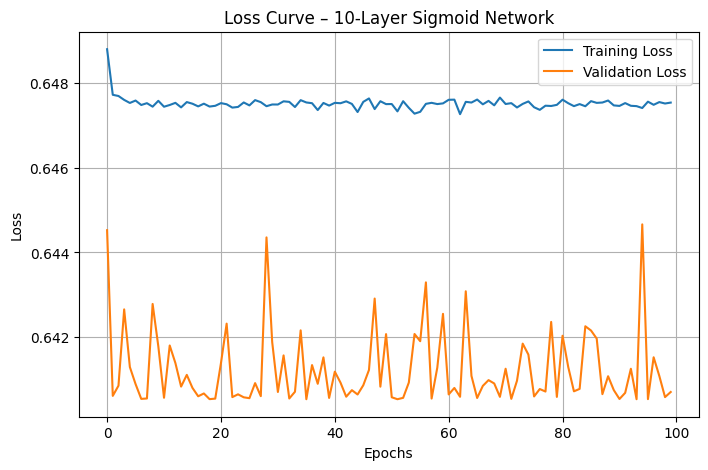

In [11]:
#10. Plot Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history_sigmoid.history['loss'], label='Training Loss')
plt.plot(history_sigmoid.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve – 10-Layer Sigmoid Network")
plt.legend()
plt.grid(True)
plt.show()


**ReLU Activation**

In [12]:
#🔹 11. Build ReLU Model
model_relu = Sequential()

model_relu.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

for _ in range(8):
    model_relu.add(Dense(64, activation='relu'))

model_relu.add(Dense(1, activation='sigmoid'))


In [13]:
#🔹 12. Compile ReLU Model
model_relu.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [14]:
#🔹 13. Train ReLU Model
history_relu = model_relu.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6547 - loss: 0.6549 - val_accuracy: 0.6607 - val_loss: 0.6414
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6503 - loss: 0.6473 - val_accuracy: 0.6607 - val_loss: 0.6405
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6470 - loss: 0.6490 - val_accuracy: 0.6607 - val_loss: 0.6408
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6530 - loss: 0.6453 - val_accuracy: 0.6607 - val_loss: 0.6407
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6542 - loss: 0.6443 - val_accuracy: 0.6607 - val_loss: 0.6407
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6517 - loss: 0.6454 - val_accuracy: 0.6607 - val_loss: 0.6403
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6515 - loss: 0.6455 - val_accuracy: 0.6607 - val_loss: 0.6406
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6489 - loss: 0

In [15]:
# Evaluate ReLU model on test data
loss_relu, acc_relu = model_relu.evaluate(
    X_test, y_test, verbose=0
)

print("\nReLU Model Performance (After ReLU)")
print(f"Test Accuracy: {acc_relu * 100:.2f}%")
print(f"Test Loss: {loss_relu:.4f}")



ReLU Model Performance (After ReLU)
Test Accuracy: 59.92%
Test Loss: 0.6976


In [16]:
print("\nAccuracy Comparison")
print(f"Before ReLU (Sigmoid): {acc_sigmoid * 100:.2f}%")
print(f"After ReLU  (ReLU):    {acc_relu * 100:.2f}%")



Accuracy Comparison
Before ReLU (Sigmoid): 65.78%
After ReLU  (ReLU):    59.92%


**Part 2**

In [17]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [18]:
# -----------------------------
# A) Load + Preprocess Dataset
# -----------------------------
data = pd.read_csv("/kaggle/input/customer-retention-dataset/Customer Retention Dataset.csv")

X = data.drop("Retention", axis=1)
y = data["Retention"].astype(int)

# one-hot encode categorical columns (e.g., ContractType)
X = pd.get_dummies(X, drop_first=True)

In [19]:
# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [20]:
def build_model(input_dim, lr=0.001):
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        Dense(64, activation="relu"),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=SGD(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [21]:
# C) Helper: Train + Time + Collect Results
# -----------------------------
def train_and_record(model, name, batch_size, epochs=50):
    start = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )
    end = time.time()

    train_time = end - start
    final_train_loss = history.history["loss"][-1]
    final_train_acc  = history.history["accuracy"][-1]
    final_val_loss   = history.history["val_loss"][-1]
    final_val_acc    = history.history["val_accuracy"][-1]

In [22]:
def train_and_record(model, name, batch_size, epochs=50):
    import time

    start = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )
    end = time.time()

    train_time = end - start

    final_train_loss = history.history["loss"][-1]
    final_train_acc  = history.history["accuracy"][-1]
    final_val_loss   = history.history["val_loss"][-1]
    final_val_acc    = history.history["val_accuracy"][-1]

    # ---- Convergence speed ----
    # epoch where loss first goes below a threshold
    threshold = 0.62
    loss_list = history.history["loss"]

    try:
        epoch_to_threshold = next(
            i + 1 for i, L in enumerate(loss_list) if L <= threshold
        )
    except StopIteration:
        epoch_to_threshold = None  # threshold not reached

    return {
        "Method": name,
        "BatchSize": batch_size,
        "TrainTime_sec": train_time,
        "Epochs": epochs,
        "FinalTrainLoss": final_train_loss,
        "FinalTrainAcc": final_train_acc,
        "FinalValLoss": final_val_loss,
        "FinalValAcc": final_val_acc,
        "EpochToLoss<=0.62": epoch_to_threshold,
        "History": history
    }


In [23]:
# D) Train 3 Variants
# -----------------------------
epochs = 100
input_dim = X_train.shape[1]

# 1) "SGD" (in practice: Keras SGD + default mini-batch training)
# We'll set batch_size=32 for SGD variant to represent standard SGD training loop.
model_sgd = build_model(input_dim, lr=0.001)
res_sgd = train_and_record(model_sgd, "SGD (standard, batch=32)", batch_size=32, epochs=epochs)

# 2) Batch Gradient Descent (full batch = all samples)
model_bgd = build_model(input_dim, lr=0.001)
res_bgd = train_and_record(model_bgd, "Batch Gradient Descent (full batch)", batch_size=len(X_train), epochs=epochs)

# 3) Mini-Batch Gradient Descent (batch size = 32)
# (Same as SGD here but explicitly labeled as mini-batch as required)
model_mbgd = build_model(input_dim, lr=0.001)
res_mbgd = train_and_record(model_mbgd, "Mini-Batch GD (batch=32)", batch_size=32, epochs=epochs)

results = [res_sgd, res_bgd, res_mbgd]

print("\n=== Model Performance Comparison ===\n")

for res in results:
    print(f"Method: {res['Method']}")
    print(f"  Final Training Loss:     {res['FinalTrainLoss']:.4f}")
    print(f"  Final Training Accuracy: {res['FinalTrainAcc']*100:.2f}%")
    print(f"  Final Validation Loss:   {res['FinalValLoss']:.4f}")
    print(f"  Final Validation Accuracy: {res['FinalValAcc']*100:.2f}%")
    print("-" * 50)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== Model Performance Comparison ===

Method: SGD (standard, batch=32)
  Final Training Loss:     0.6418
  Final Training Accuracy: 65.34%
  Final Validation Loss:   0.6443
  Final Validation Accuracy: 65.44%
--------------------------------------------------
Method: Batch Gradient Descent (full batch)
  Final Training Loss:     0.6675
  Final Training Accuracy: 63.22%
  Final Validation Loss:   0.6661
  Final Validation Accuracy: 63.90%
--------------------------------------------------
Method: Mini-Batch GD (batch=32)
  Final Training Loss:     0.6417
  Final Training Accuracy: 65.34%
  Final Validation Loss:   0.6447
  Final Validation Accuracy: 65.44%
--------------------------------------------------


In [24]:
# -----------------------------
# E) Make Comparison Table
# -----------------------------
summary = pd.DataFrame([{
    "Method": r["Method"],
    "BatchSize": r["BatchSize"],
    "TrainTime_sec": round(r["TrainTime_sec"], 2),
    "FinalTrainLoss": round(r["FinalTrainLoss"], 4),
    "FinalTrainAcc(%)": round(r["FinalTrainAcc"]*100, 2),
    "FinalValLoss": round(r["FinalValLoss"], 4),
    "FinalValAcc(%)": round(r["FinalValAcc"]*100, 2),
    "EpochToLoss<=0.62": r["EpochToLoss<=0.62"]
} for r in results])

print(summary)

                                Method  BatchSize  TrainTime_sec  \
0             SGD (standard, batch=32)         32         181.76   
1  Batch Gradient Descent (full batch)      40000           9.57   
2             Mini-Batch GD (batch=32)         32         178.04   

   FinalTrainLoss  FinalTrainAcc(%)  FinalValLoss  FinalValAcc(%)  \
0          0.6418             65.34        0.6443           65.44   
1          0.6675             63.22        0.6661           63.90   
2          0.6417             65.34        0.6447           65.44   

  EpochToLoss<=0.62  
0              None  
1              None  
2              None  


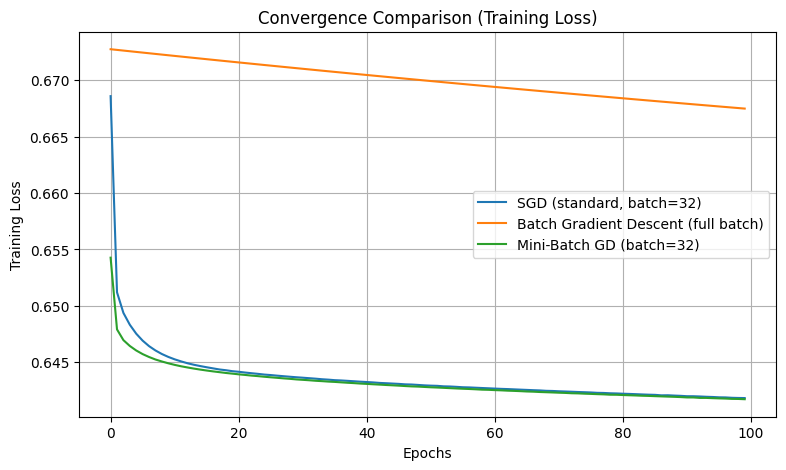

In [25]:
# -----------------------------
# F) Plot Loss Curves for Convergence Speed
# -----------------------------
plt.figure(figsize=(9,5))
for r in results:
    plt.plot(r["History"].history["loss"], label=r["Method"])
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Convergence Comparison (Training Loss)")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# -----------------------------
# G) Optional: Evaluate on Test Set
# -----------------------------
print("\nTest Set Evaluation:")
for r, model in [(res_sgd, model_sgd), (res_bgd, model_bgd), (res_mbgd, model_mbgd)]:
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{r['Method']} -> Test Acc: {test_acc*100:.2f}%, Test Loss: {test_loss:.4f}")


Test Set Evaluation:
SGD (standard, batch=32) -> Test Acc: 65.36%, Test Loss: 0.6446
Batch Gradient Descent (full batch) -> Test Acc: 63.01%, Test Loss: 0.6677
Mini-Batch GD (batch=32) -> Test Acc: 65.36%, Test Loss: 0.6454


In [38]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

In [28]:
# -----------------------------
# 1) Load + Preprocess Dataset
# -----------------------------
data = pd.read_csv("/kaggle/input/customer-retention-dataset/Customer Retention Dataset.csv")

X = data.drop("Retention", axis=1)
y = data["Retention"].astype(int)

In [29]:
# One-hot encode categorical columns (e.g., ContractType)
X = pd.get_dummies(X, drop_first=True)

# Train-test split (use stratify for balanced split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [31]:
# -----------------------------
# 2) Build Model (3 hidden layers)
# -----------------------------
def build_model(input_dim, activation_name):
    model = Sequential()

    if activation_name == "leaky_relu":
        # Hidden Layer 1
        model.add(Dense(64, input_shape=(input_dim,)))
        model.add(LeakyReLU(alpha=0.01))
        # Hidden Layer 2
        model.add(Dense(64))
        model.add(LeakyReLU(alpha=0.01))
        # Hidden Layer 3
        model.add(Dense(64))
        model.add(LeakyReLU(alpha=0.01))
    else:
        model.add(Dense(64, activation=activation_name, input_shape=(input_dim,)))
        model.add(Dense(64, activation=activation_name))
        model.add(Dense(64, activation=activation_name))

    # Output layer for binary classification
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [32]:
# -----------------------------
# -----------------------------
# 3) Train + Record Metrics
def train_and_record(model, name, epochs=50, batch_size=32):
    start = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )
    end = time.time()

    train_time = end - start
    final_train_loss = history.history["loss"][-1]
    final_train_acc  = history.history["accuracy"][-1]
    final_val_loss   = history.history["val_loss"][-1]
    final_val_acc    = history.history["val_accuracy"][-1]

    # Convergence speed metric: epoch where val_loss reaches its minimum
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    best_val_loss = float(np.min(history.history["val_loss"]))

    return {
        "Activation": name,
        "TrainTime_sec": train_time,
        "FinalTrainLoss": final_train_loss,
        "FinalTrainAcc": final_train_acc,
        "FinalValLoss": final_val_loss,
        "FinalValAcc": final_val_acc,
        "BestEpoch_valLoss": best_epoch,
        "BestValLoss": best_val_loss,
        "History": history
    }

In [33]:
# -----------------------------
# 4) Train 4 Models
# -----------------------------
epochs = 100
input_dim = X_train.shape[1]

activations = [
    ("sigmoid", "Sigmoid"),
    ("tanh", "Tanh"),
    ("relu", "ReLU"),
    ("leaky_relu", "Leaky ReLU")
]

results = []
models = {}

for act_key, act_name in activations:
    model = build_model(input_dim, act_key)
    res = train_and_record(model, act_name, epochs=epochs, batch_size=32)
    results.append(res)
    models[act_name] = model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [34]:
# -----------------------------
# 5) Summary Table
# -----------------------------
summary = pd.DataFrame([{
    "Activation": r["Activation"],
    "TrainTime_sec": round(r["TrainTime_sec"], 2),
    "FinalTrainLoss": round(r["FinalTrainLoss"], 4),
    "FinalTrainAcc(%)": round(r["FinalTrainAcc"]*100, 2),
    "FinalValLoss": round(r["FinalValLoss"], 4),
    "FinalValAcc(%)": round(r["FinalValAcc"]*100, 2),
    "BestEpoch(val_loss)": r["BestEpoch_valLoss"],
    "BestValLoss": round(r["BestValLoss"], 4)
} for r in results])

print("\n=== Activation Function Comparison (Validation) ===\n")
print(summary.sort_values(by="FinalValAcc(%)", ascending=False))



=== Activation Function Comparison (Validation) ===

   Activation  TrainTime_sec  FinalTrainLoss  FinalTrainAcc(%)  FinalValLoss  \
0     Sigmoid         181.15          0.6389             65.45        0.6493   
1        Tanh         182.32          0.5947             68.27        0.6977   
2        ReLU         185.03          0.4552             78.48        0.9590   
3  Leaky ReLU         186.71          0.4593             77.63        0.9542   

   FinalValAcc(%)  BestEpoch(val_loss)  BestValLoss  
0           65.06                   13       0.6441  
1           60.85                    7       0.6442  
2           57.40                    2       0.6453  
3           55.62                    6       0.6449  


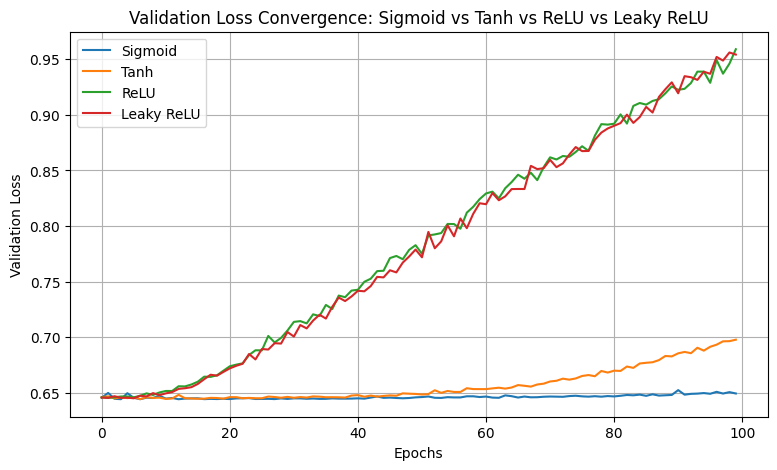

In [35]:
# -----------------------------
# 6) Plot Validation Loss Curves (Convergence)
# -----------------------------
plt.figure(figsize=(9,5))
for r in results:
    plt.plot(r["History"].history["val_loss"], label=r["Activation"])
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Convergence: Sigmoid vs Tanh vs ReLU vs Leaky ReLU")
plt.legend()
plt.grid(True)
plt.show()

In [36]:

# -----------------------------
# 7) Choose Best Activation (by Validation Accuracy)
# -----------------------------
best = max(results, key=lambda x: x["FinalValAcc"])
print("\nBest Activation (by Final Validation Accuracy):", best["Activation"])
print(f"Final Val Accuracy: {best['FinalValAcc']*100:.2f}%")
print(f"Final Val Loss: {best['FinalValLoss']:.4f}")
print(f"Training Time: {best['TrainTime_sec']:.2f} sec")



Best Activation (by Final Validation Accuracy): Sigmoid
Final Val Accuracy: 65.06%
Final Val Loss: 0.6493
Training Time: 181.15 sec
